In [3]:
!pip install lightkurve --quiet

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 1.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 261.1/261.1 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 69.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.6/206.6 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 56.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.4/15.4 MB 66.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
datasets 4.0.0 requires fsspec[http]<=2025.3.0,>=2023.1.0, but you have fsspec 2026.7.0 which is incompatible

In [4]:
import lightkurve as lk

search_result = lk.search_lightcurve("TIC 25155310", mission="TESS")
print(search_result)

/usr/local/lib/python3.12/dist-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


SearchResult containing 235 data products.

 #     mission     year       author      exptime target_name distance
                                             s                 arcsec 
--- -------------- ---- ----------------- ------- ----------- --------
  0 TESS Sector 01 2018              SPOC     120    25155310      0.0
  1 TESS Sector 02 2018              SPOC     120    25155310      0.0
  2 TESS Sector 03 2018              SPOC     120    25155310      0.0
  3 TESS Sector 04 2018              SPOC     120    25155310      0.0
  4 TESS Sector 05 2018              SPOC     120    25155310      0.0
  5 TESS Sector 06 2018              SPOC     120    25155310      0.0
  6 TESS Sector 07 2019              SPOC     120    25155310      0.0
  7 TESS Sector 08 2019              SPOC     120    25155310      0.0
  8 TESS Sector 09 2019              SPOC     120    25155310      0.0
  9 TESS Sector 10 2019              SPOC     120    25155310      0.0
 10 TESS Sector 11 2019          

In [5]:
lc = search_result[0].download()

In [6]:
import lightkurve as lk
from pathlib import Path

# Create a folder for the downloaded data
data_dir = Path("tess_data")
data_dir.mkdir(exist_ok=True)

# Download only the first search result
lc = search_result[0].download(download_dir=str(data_dir))

print(lc)


       time             flux      ...   pos_corr1      pos_corr2   
                    electron / s  ...      pix            pix      
------------------ -------------- ... -------------- --------------
1325.2966258808235  9.2627041e+03 ...  2.9971417e-02 -6.6027217e-02
1325.2980147804474  9.2711973e+03 ... -4.2239105e-04 -1.0025273e-01
 1325.299403680013  9.2906729e+03 ... -1.2138215e-03 -1.0391606e-01
1325.3007925795785  9.2628174e+03 ... -2.9799975e-03 -1.1566762e-01
1325.3021814792023  9.2777139e+03 ... -9.8572923e-03 -1.1535366e-01
 1325.303570378768  9.2604170e+03 ... -1.0768156e-02 -1.1588433e-01
1325.3049592783916  9.2684199e+03 ... -6.7567211e-03 -1.2002597e-01
1325.3063481780152  9.2672148e+03 ... -8.2860291e-03 -1.1578123e-01
 1325.307737077639  9.2526143e+03 ... -1.2014245e-02 -1.1912200e-01
               ...            ... ...            ...            ...
1353.1648095155513  9.2582285e+03 ... -1.6124731e-02 -5.4954281e-03
1353.1661984014393  9.2979814e+03 ... -1.2574126

<Axes: xlabel='Time - 2457000 [BTJD days]', ylabel='Flux [$\\mathrm{e^{-}\\,s^{-1}}$]'>

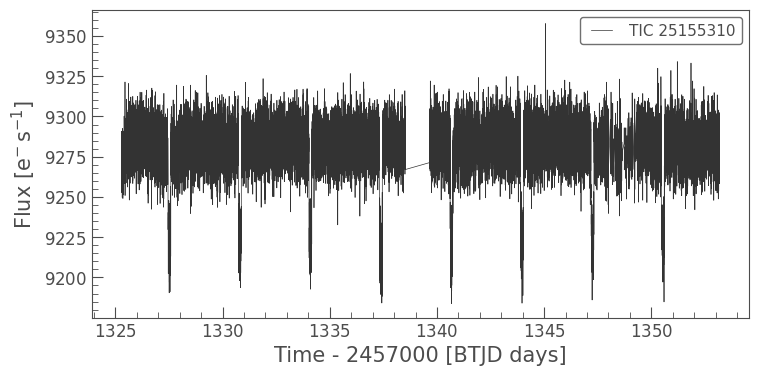

In [7]:
lc.plot()

Look at the plot. Those aren't just noisy fluctuations. there are **regular, sharp, periodic dips** (around 1327, 1330, 1334, 1337, 1341, 1344, 1347, 1351...) dropping from ~9280 down to ~9190-9200. That's not noise. That's very likely a real **periodic signal** (possibly a transiting exoplanet or an eclipsing binary).



In [8]:
len(lc)

18278

In [9]:
lc.flux.mean()

<MaskedQuantity 9280.361 electron / s>

In [10]:
lc.flux.std()

<MaskedQuantity 17.207655 electron / s>

In [11]:
lc.flux_err.mean()

<MaskedQuantity 12.633817 electron / s>

std(*flux*) = 17.2, mean *flux_err* = 12.6

std(flux) / mean (flux_err) == 1.4

So the empirical scatter is about 40% larger than the stated per-point uncertainty. Is that a red flag? Not necessarily.

Explanation:  

*   A ratio of 1.0 would mean the scatter matches the expected uncertainty perfectly.


*   A ratio of 1.4 means the actual variation in the data is 1.4 times (or 40% larger than) the expected uncertainty.




In [12]:
lc_2 = search_result[12].download(download_dir=str(data_dir))

print(lc_2)

       time             flux      ...   pos_corr1      pos_corr2   
                    electron / s  ...      pix            pix      
------------------ -------------- ... -------------- --------------
1653.9210220436732            ——— ...  4.2217225e-03  8.8680303e-03
 1653.922410953274            ——— ...  6.0018636e-03  7.2530173e-03
1653.9237998628466            ——— ...  4.6402784e-03  5.3792708e-03
1653.9251887724179            ——— ...  2.1290188e-03  4.7757206e-03
1653.9265776820182            ——— ...  9.1334041e-03  1.2269227e-02
 1653.927966591648            ——— ...  5.1346333e-03  7.9735564e-03
1653.9293555012484            ——— ...  2.0903447e-03  6.9771325e-03
1653.9307444108788            ——— ...  7.5811776e-03  7.5196824e-03
1653.9321333205094            ——— ...  7.8059500e-03  1.0291535e-02
               ...            ... ...            ...            ...
1682.3450073360357  9.1163125e+03 ...  1.2263929e-02  6.8064384e-02
 1682.346396236847  9.0932158e+03 ...  8.9357635

I'm checking the [12] data to test that calculation again.

(12 TESS Sector 13 2019              SPOC     120    25155310)

In [13]:
len(lc_2)

19439

In [14]:
lc_2.flux.mean()

<MaskedQuantity 9088.405 electron / s>

In [15]:
lc_2.flux.std()

<MaskedQuantity 16.998978 electron / s>

In [16]:
lc_2.flux_err.mean()

<MaskedQuantity 12.826725 electron / s>

In [17]:
lc_2.flux.std() / lc_2.flux_err.mean()

<MaskedQuantity 1.325278>

<Axes: xlabel='Time - 2457000 [BTJD days]', ylabel='Flux [$\\mathrm{e^{-}\\,s^{-1}}$]'>

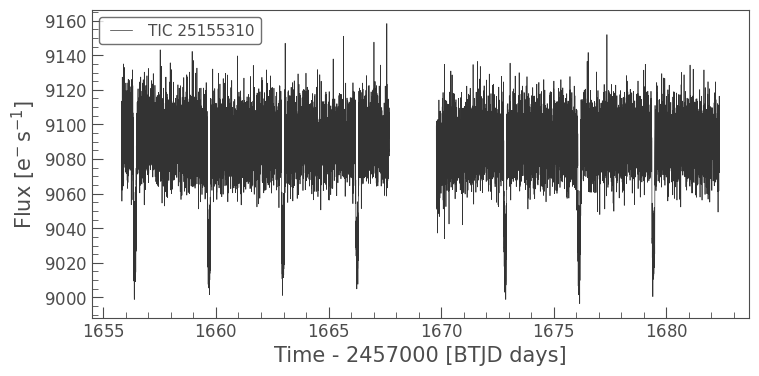

In [19]:
lc_2.plot()

Let us check again to compere the current plot.
